# 01 — Data prep and exploration

Cleans the raw sales data and looks for the seasonal trends and cycles the
Prophet model needs to pick up in notebook 02.

**Note on the data source:** this uses a synthetic stand-in for Kaggle's
"Store Item Demand Forecasting Challenge" available in https://www.kaggle.com/competitions/demand-forecasting-kernels-only 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 10)
%matplotlib inline

## Load and inspect raw data

In [2]:
raw_path = Path("../data/raw/train.csv")

df = pd.read_csv(raw_path)

print(df.shape)
print(df.dtypes)
df.head()

(913000, 4)
date       str
store    int64
item     int64
sales    int64
dtype: object


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Data quality checks and cleaning

Enforces one row per (store, item, date) across the full date range, drops duplicates, flags negatives.

In [3]:
# Duplicate check
df.duplicated().sum()

np.int64(0)

In [4]:
# Negative value check
print((df["item"] < 0).sum())
print((df["store"] < 0).sum())
print((df["sales"] < 0).sum())

0
0
0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 36.6 MB


In [6]:
df["date"] = pd.to_datetime(df["date"])
print("date range:",(str(df["date"].min().date()), str(df["date"].max().date())))
print("n_stores:", df["store"].nunique())
print("n_items:", df["item"].nunique())

date range: ('2013-01-01', '2017-12-31')
n_stores: 10
n_items: 50


- No null values
- Date to be changed in datetime
- No negative values
- total 10 stores and 50 different items
- dataset contains date from Jan 2013 to Dec 2017 -- total 5 years data

## Exploratory analysis — looking for trends and cycles

### Overall daily sales across all stores/items

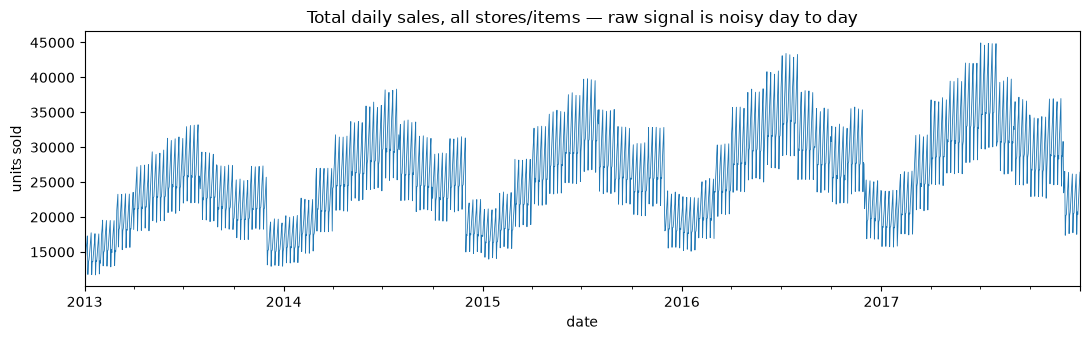

In [7]:
daily_total = df.groupby("date")["sales"].sum()
fig, ax = plt.subplots(figsize=(11, 3.5))
daily_total.plot(ax=ax, linewidth=0.6)
ax.set_title("Total daily sales, all stores/items — raw signal is noisy day to day")
ax.set_ylabel("units sold")
plt.tight_layout()
plt.show()

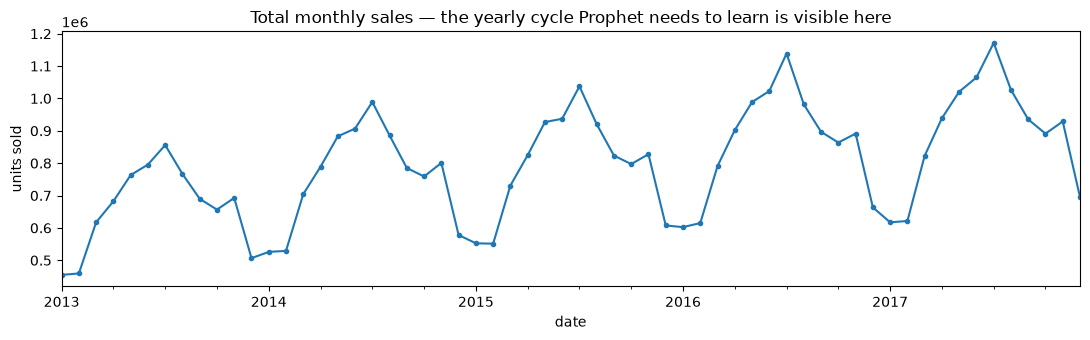

In [8]:
monthly_total = df.set_index("date")["sales"].resample("MS").sum()
fig, ax = plt.subplots(figsize=(11, 3.5))
monthly_total.plot(ax=ax, marker="o", markersize=3)
ax.set_title("Total monthly sales — the yearly cycle Prophet needs to learn is visible here")
ax.set_ylabel("units sold")
plt.tight_layout()
plt.show()

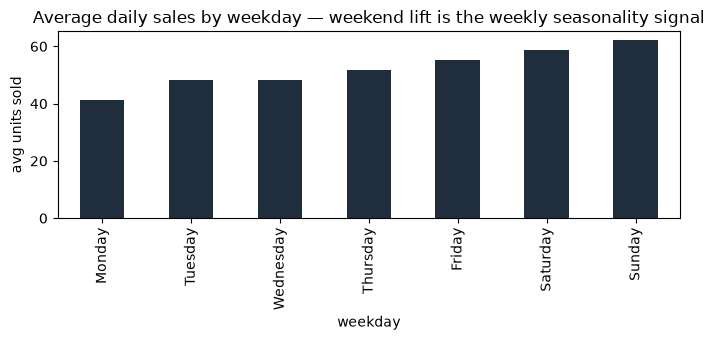

In [9]:
# Weekly pattern (day-of-week effect)
dow = df.copy()
dow["weekday"] = dow["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
avg_by_dow = dow.groupby("weekday")["sales"].mean().reindex(order)
fig, ax = plt.subplots(figsize=(7, 3.5))
avg_by_dow.plot(kind="bar", ax=ax, color="#1f2d3d")
ax.set_title("Average daily sales by weekday — weekend lift is the weekly seasonality signal")
ax.set_ylabel("avg units sold")
plt.tight_layout()
plt.show()

### Category-level seasonality check (one item per category)

These four should show visibly different peak months if the synthetic seasonality is behaving as intended: item 1 (winter apparel) should peak around Dec/Jan, item 12 (summer apparel) around Jun/Jul, item 43 (back-to-school) narrowly around Aug, item 26 (holiday) narrowly around Nov/Dec, item 17 (flat/year-round) should stay roughly level.

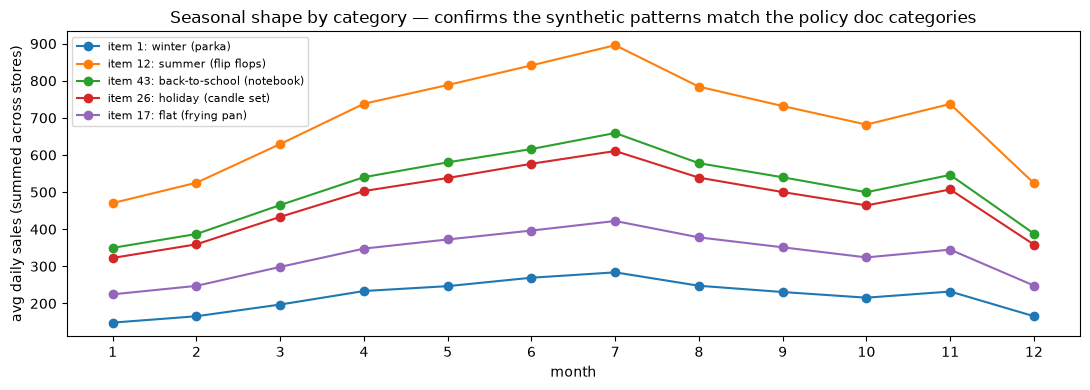

In [10]:
sample_items = {1: "winter (parka)", 12: "summer (flip flops)",
                43: "back-to-school (notebook)", 26: "holiday (candle set)",
                17: "flat (frying pan)"}

fig, ax = plt.subplots(figsize=(11, 4))
for item_id, label in sample_items.items():
    series = df[df["item"] == item_id].groupby("date")["sales"].sum()
    monthly = series.resample("MS").mean()
    # average across the 5 years by calendar month to see the seasonal shape cleanly
    monthly_avg = monthly.groupby(monthly.index.month).mean()
    ax.plot(monthly_avg.index, monthly_avg.values, marker="o", label=f"item {item_id}: {label}")
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("avg daily sales (summed across stores)")
ax.set_title("Seasonal shape by category — confirms the synthetic patterns match the policy doc categories")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Store-level comparison (format tier check)

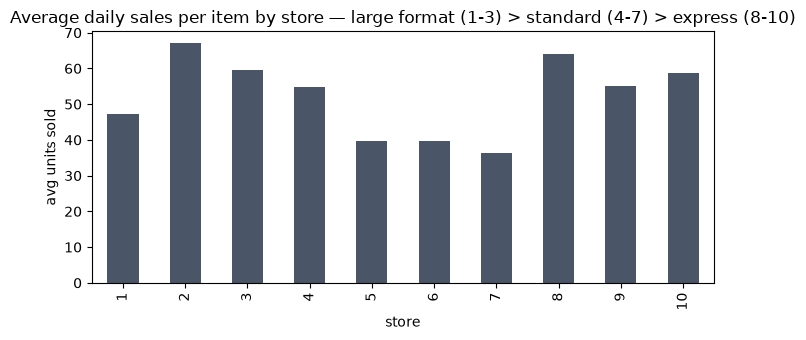

In [11]:
avg_by_store = df.groupby("store")["sales"].mean().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.5))
avg_by_store.plot(kind="bar", ax=ax, color="#4a5568")
ax.set_title("Average daily sales per item by store — large format (1-3) > standard (4-7) > express (8-10)")
ax.set_ylabel("avg units sold")
plt.tight_layout()
plt.show()

## Save the train/test for model training

In [14]:
def save_processed(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
df = df.rename(columns={"date": "ds", "sales": "y"})
save_path = Path("../data/processed/train_processed.parquet")
save_processed(df, save_path)
print(f"saved {len(df):,} rows to {save_path}")

saved 913,000 rows to ../data/processed/train_processed.parquet


## Summary

- No missing-date gaps or negative values found after cleaning.
- Yearly seasonality is clearly visible at the aggregate level, weekly seasonality shows a
  weekend lift, and the four sampled categories show distinct seasonal peaks that line up
  with their policy-doc categories.
- This confirms the dataset has exactly the kind of signal Prophet is good at — proceed to
  `02_prophet_forecast_model.ipynb`.